# Classification - Logistic Regression

-----------------------

반응변수가 질적 변수인 경우들이 많이 있다.

질적 변수들의 예:

\begin{align*}
&\textrm{eye color} \in \{ \textrm{brown}, \textrm{blue}, \textrm{green} \}  \\
&\textrm{email} \in \{\textrm{spam}, \textrm{ham} \} 
\end{align*}

질적 반응변수를 예측하는 분류 (classfication)에 대해 알아보자. 크게 두 가지 방법이 있다.

* 주어진 입력 변수 $X$에 대해 클래스를 결정하는 함수 $C(X)$를 찾는 방법  
* 입력 변수 $X$가 특정 클래스들에 속하는 확률들을 구하는 방법

두 개의 클래스인 경우 반응변수를 0과 1로 코딩하여 선형회귀를 적용할 수도 있다. 그러나 예측값이 0과 1 사이를 벗어날 수 있으므로 확률모형으로는 적절하지 않다.

특정 조건에서는 선형회귀와 나중에 살펴볼 linear discriminant analysis가 유사한 선형 결정경계를 만들 수 있다.

하지만, 클래스의 숫자가 늘어나면 선형회귀 방법은 적용하기 어렵다. 

예를 들어, 응급실에 환자가 도착한 경우, 증상에 따른 분류를 다음의 숫자들로 치환하여 선형회귀를 진행하는 경우를 가정해 보자.

$$
    Y = 
\begin{cases}
    1, & \text{if stroke;} \\
    2, & \text{if drug overdose;} \\
    3, & \text{if epileptic seizure.}
\end{cases}
$$

하지만, 위 코딩은 $Y$에 순서 구조와 거리 구조를 강제하며, 이는 질적 변수의 특징이 아니다.

따라서 분류를 위해 특별히 고안된 방법들을 사용하는 것이 좋겠다.

## Logistic regression

balance라는 입력 변수를 이용하여 default의 여부를 예측하는 문제를 생각해 보자. Default에 대한 반응변수 $Y$는 다음과 같이 코딩한다.

$$
    Y = 
\begin{cases}
    0, & \text{if No;} \\
    1, & \text{if Yes.} 
\end{cases}
$$

주어진 $X$에 대해 default가 발생할 확률을 다음과 같이 표현하자.

$$ p(X) = \mathbb P (Y = 1 | X)$$

따라서,

$$ 1 - p(X) = \mathbb P (Y = 0 | X)$$

Logistic regression에서는 다음의 식을 가정한다.

$$ p(X) = \frac{e^{\theta_0 + \theta_1 X}}{1 + e^{\theta_0 + \theta_1 X}} = \frac{1}{1 + e^{-\theta_0 - \theta_1 X }} $$

위와 같이 가정하면 $\theta$나 $X$의 값에 상관없이 $p(X)$는 항상 0과 1 사이의 값을 취한다.

또한, 위 식은 다음으로도 표현되며, 이 값은 $p(X)$의 log odds 혹은 logit transformation이라고도 불리운다.

$$ \log \left( \frac{p(X)}{1 - p(X)}\right)  = \theta_0 + \theta_1 X $$

### Sigmoid function

한편,

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

를 sigmoid 함수라고 부르며, 이진 분류 문제에서 자주 등장하는 함수이다.

Sigmoid 함수는 실수값을 0과 1 사이의 값으로 변환한다. 로지스틱 회귀에서는 이를 클래스 1에 속할 확률로 해석한다.

Logistic regression에서는 $z=\theta_0+\theta_1X$로 두고 sigmoid 함수를 적용하여 확률을 계산한다.

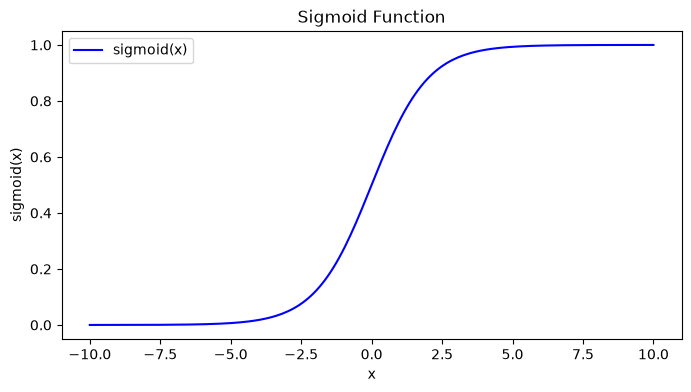

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid 함수 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 200)
y = sigmoid(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='sigmoid(x)', color='blue')
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.legend()
plt.show()

### Maximum likelihood method

위 확률모형의 $\theta$들을 추정하기 위한 전통적인 방법으로 maximum likelihood estimation (MLE)가 있다.

관찰값 $\{x_i, y_i \}$들이 주어졌을 때, logistic regression의 모수 $\theta_0, \theta_1$을 추정하기 위해, likelihood 함수를 정의하자.

$$ L (\theta_0, \theta_1) = \prod_{i:y_i=1} p(x_i) \prod_{i:y_i=0}(1-p(x_i)) $$

여기서 

$$p(x_i) = p_i = \frac{e^{\theta_0 + \theta_1 x_i}}{1 + e^{\theta_0 + \theta_1 x_i}} = \frac{1}{1 + e^{-\theta_0 - \theta_1 x_i}} $$ 

이므로 위 식의 우변은 $\theta_0, \theta_1$의 함수이다.

추정량 $\hat \theta_0, \hat \theta_1$은 $L (\theta_0, \theta_1)$를 최대화하는 값들로 다음으로 표현된다.

$$ \hat \theta_0, \hat \theta_1 = \arg \max_{\theta_0, \theta_1} L (\theta_0, \theta_1) $$

이는 log-likelihood 함수를 최대화하는 것과 동치이다.

$$ \hat \theta_0, \hat \theta_1 = \arg \max_{\theta_0, \theta_1} \log L (\theta_0, \theta_1) = \arg \max_{\theta_0, \theta_1}  \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i)\log(1- p_i) \right]$$

$\hat \theta_0, \hat \theta_1$의 추정치가 결정되면 이를 이용하여 주어진 $X$에 대해 default 확률을 추정할 수 있다.

$$ \hat p(X) = \frac{e^{\hat \theta_0 + \hat \theta_1 X}}{1 + e^{\hat \theta_0 + \hat \theta_1 X}} $$

## 여러 입력변수로 확장

로지스틱 회귀는 자연스럽게 여러 입력변수를 가지는 모형으로도 확장 가능하다.

$$ \log \left( \frac{p(X)}{1 - p(X)}\right)  = \theta_0 + \theta_1 X_1 + \cdots + \theta_p X_p  $$

혹은,

$$ p(X) = \frac{e^{\theta_0 + \theta_1 X_1 + \cdots + \theta_p X_p}}{1 + e^{\theta_0 + \theta_1 X_1 + \cdots + \theta_p X_p}} =  \frac{1}{1 + e^{-\theta_0 - \theta_1 X_1 - \cdots - \theta_p X_p}}$$


## 로지스틱 회귀의 gradient vector

앞서 공부한 경사하강법은 로지스틱 회귀방법에도 적용 가능하다.

### 비용함수

훈련 샘플 하나에 대한 손실 함수를 다음으로 두자.

$$ c(\boldsymbol{\theta}) = \left\{\begin{array}{lr}
        -\log(p), & \text{if } y = 1\\
        -\log(1 - p), & \text{if } y = 0\\
        \end{array}\right.
$$

이 손실 함수를 binary cross entropy 또는 log loss라고도 부르며, 이진 분류 문제를 다룰 때 널리 사용된다.

이를 전체 샘플에 평균으로 적용하여 확장하면, 비용함수는 결국 음의 log-likelihood 함수를 $N$으로 나눈 값 ($J(\boldsymbol{\theta}) = -\frac{1}{N}\log L(\boldsymbol{\theta})$)으로, 즉 전체 자료의 binary cross-entropy는 평균 음의 log-likelihood와 같다.

$$ J(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i)\log(1- p_i) \right]$$
이며, 여기서
$$ \ p_i = \sigma(\boldsymbol{\theta} \cdot x_i) = \frac{1}{1 + \exp( - \boldsymbol{\theta} \cdot x_i)} = \frac{1}{1 + \exp( - \theta_0 - x_{i1} \theta_1 - \cdots -  x_{ip} \theta_p )}. $$

> 즉, binary cross entropy 비용 함수를 최소화하는 것은, 로지스틱 회귀 모델의 likelihood 함수를 최대화하는 것과 동치이다.

### Gradient vector

다음의 시그모이드 함수에 대해
$$ \sigma(t) = \frac{1}{1 + \exp(-t)} $$
미분은
$$ \frac{d}{d t}\sigma(t) = \sigma(t) (1 - \sigma(t))$$
와 같이 주어지므로, 비용함수의 편미분을 다음과 같이 계산할 수 있다.

\begin{align*}
\frac{\partial }{\partial \theta_j} J(\boldsymbol{\theta}) &= -\frac{1}{N} \sum_{i=1}^{N} 
\left[ y_i  \frac{ \frac{\partial }{\partial \theta_j} \sigma(\boldsymbol{\theta} \cdot x_i)}{\sigma(\boldsymbol{\theta} \cdot x_i)} + (1 - y_i)  \frac{ \frac{\partial }{\partial \theta_j} \left\{ 1 - \sigma(\boldsymbol{\theta} \cdot x_i) \right\} }{1 - \sigma(\boldsymbol{\theta} \cdot x_i)} \right]\\
&= -\frac{1}{N} \sum_{i=1}^{N} 
\left[ y_i  \frac{\sigma(\boldsymbol{\theta} \cdot x_i)(1 - \sigma(\boldsymbol{\theta} \cdot x_i)) }{\sigma(\boldsymbol{\theta} \cdot x_i)}x_{ij} + (1 - y_i)  \frac{ -\sigma(\boldsymbol{\theta} \cdot x_i)(1 - \sigma(\boldsymbol{\theta} \cdot x_i)) } {1 - \sigma(\boldsymbol{\theta} \cdot x_i)}x_{ij} \right] \\
&= - \frac{1}{N}  \sum_{i=1}^{N} \left[ y_i - \sigma(\boldsymbol{\theta} \cdot x_i) y_i - \sigma(\boldsymbol{\theta} \cdot x_i) + \sigma(\boldsymbol{\theta} \cdot x_i) y_i \right] x_{ij} \\
& = \frac{1}{N}  \sum_{i=1}^{N} \left[ \sigma(\boldsymbol{\theta} \cdot x_i) - y_i\right] x_{ij} \\
& = \frac{1}{N}  \mathbf x_j^{\top} ( \sigma(\mathbf X_b \boldsymbol{\theta}) - \mathbf y).
\end{align*}

여기서
- $\mathbf{X}_b = [\mathbf{1}, \mathbf{X}]$
- $x_i = [1, x_{i1}, \dots, x_{ip}]$

따라서 비용함수의 gradient vector는
\begin{equation*}
\nabla_\theta J (\boldsymbol{\theta}) =  \frac{1}{N} \mathbf X_b^{\top} ( \sigma(\mathbf X_b \boldsymbol{\theta}) - \mathbf y) = \frac{1}{N} \mathbf X_b^{\top} \left( \frac{1}{1 + \exp(- \mathbf X_b \boldsymbol{\theta})} - \mathbf y \right)
\end{equation*}
이다.

$$
\mathbf{p} := \sigma(\mathbf X_b \boldsymbol{\theta}) = \frac{1}{1 + \exp(- \mathbf X_b \boldsymbol{\theta})}
$$

로 정의하면, gradient는 다음과 같이 간단하게도 쓸 수 있다.

$$ \nabla_\theta J (\boldsymbol{\theta}) = \frac{1}{N} \mathbf X_b^{\top} (\mathbf{p} - \mathbf{y}) $$

- $(\mathbf{p} - \mathbf{y})$ : 예측 확률 벡터 $\mathbf{p}$와 정답 벡터 $\mathbf{y}$의 차이

현재의 $\boldsymbol{\theta}$에서 다음 스텝에서의 $\boldsymbol{\theta}^{\text{(next step)}}$는 다음과 같다.

$$ \boldsymbol{\theta}^{\text{(next step)}} = \boldsymbol{\theta} - \eta \nabla_\theta J (\theta) $$

물론 logistic regression을 진행하기 위해 매번 gradient를 계산하는 코드를 직접 작성할 필요는 없다.  
```sklearn.linear_model.LogisticRegression```을 이용하여 예제를 진행해 본다.

### 예제 : Iris dataset example

[Iris Dataset](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html) 을 이용한 예제를 진행해 보자.

In [2]:
from sklearn import datasets
iris = datasets.load_iris()

In [3]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

4개의 feature variable $X$들이 있다.

In [4]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

타겟 변수 $y$는 3종류의 클래스로 붓꽃의 품종을 나타낸다.

In [5]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
import pandas as pd
pd.DataFrame(iris["data"], columns=iris["feature_names"])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


먼저 $X =$ petal width로 놓고, 이 때 붓꽃의 품종이 virginica인가 아닌가를 판단하는 예제를 진행해 보자.  

In [7]:
import numpy as np
X = iris["data"][:, 3:] # petal width
y = (iris["target"] == 2).astype(int)  # virginica인가, 아닌가로 구분
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
pd.DataFrame(np.c_[X, y], columns=("petal width", "virginica"))

,petal width,virginica
0,0.2,0.0
1,0.2,0.0
2,0.2,0.0
3,0.2,0.0
4,0.2,0.0
...,...,...
145,2.3,1.0
146,1.9,1.0
147,2.0,1.0
148,2.3,1.0


진행하기에 앞서 앞 단원에서 했던 것처럼, 직접 gradient를 이용하여 $\theta$를 추정해 보자.

In [9]:
Xb = np.c_[np.ones((X.shape[0], 1)), X]

eta = 0.05
n_iteration = 20000
N = len(y)

theta = np.array([[0],[0]])
evolution = np.ravel(theta)

for _ in range(n_iteration):
    grad = 1 / N * Xb.T @ ( 1 / (1 + np.exp(-Xb @ theta)) - y.reshape(-1,1))
    # update theta
    theta = theta - eta * grad
    evolution = np.vstack((evolution, np.ravel(theta)))

theta

array([[-12.36961123],
       [  7.56309795]])

In [10]:
# 새로운 테스트 값에 대해 확률 예측
xtest = 2
np.exp(theta[0,0] + theta[1,0] * xtest) / (1 + np.exp(theta[0,0] + theta[1,0] * xtest))

np.float64(0.9402841518512881)

log-likelihood 함수가 어떻게 생겼는지 살펴보자.  

In [11]:
def llf(theta, X, y):
    llh = 0
    for i in range(X.shape[0]):
        p = 1 / (1 + np.exp(-  X[i,:] @ theta))
        llh += y[i] * np.log(p) + (1 - y[i]) * np.log(1 - p)
    return llh               

In [12]:
theta1 = np.linspace(-30, 0, 100)
theta2 = np.linspace(0, 14, 100)
Theta1, Theta2 = np.meshgrid(theta1, theta2)

Z = np.zeros_like(Theta1)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        Z[i,j] = -llf([Theta1[i,j], Theta2[i,j]], Xb, y)

아래 그림은 음의 log-likelihood를 나타낸다. 함수는 최솟값 부근에서 비교적 평평하다.

- 목적함수가 평평하면 계수 추정치가 자료의 작은 변화에 민감할 수 있다.

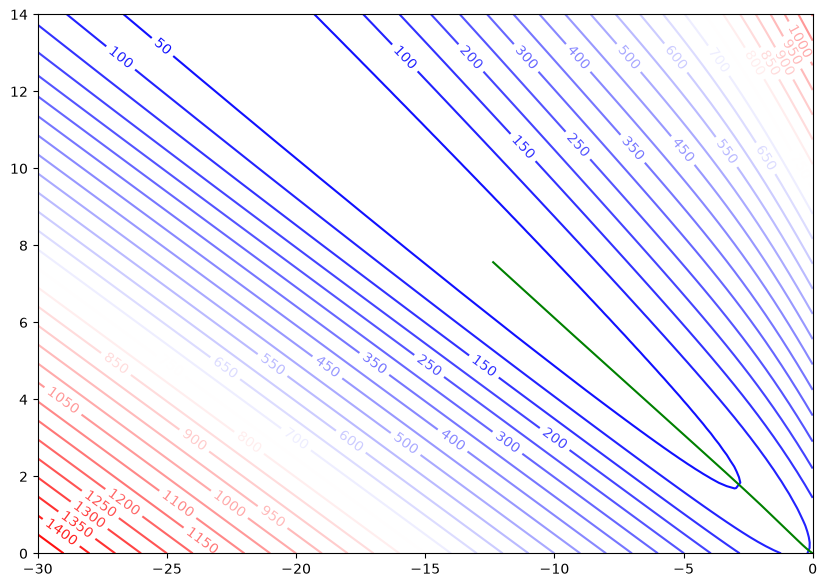

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig = plt.figure(figsize = (10,7))

#contour plot for LLF

contours = plt.contour(Theta1, Theta2, Z, 
                       levels = 30, 
                       cmap=mpl.cm.bwr)
plt.clabel(contours, inline = True, fontsize = 10)
plt.plot(evolution[:,0], evolution[:,1], color='green')

plt.show()

### ```sklearn.linear_model.LogisticRegression```

[sklearn.linear_model.LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)을 이용하여 간단히 구현할 수 있다.


```LogisticRegression()``` : 생성자

* ```fit()``` : 모델 훈련

* ```predict_proba()``` : 확률 예측

* ```predict()``` : class label 예측

* `score()` : 정확도 계산

In [14]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

In [15]:
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [16]:
log_reg.intercept_, log_reg.coef_

(array([-7.19342106]), array([[4.33251974]]))

어떤 numerical solver를 사용하냐에 따라 추정치가 달라질 수 있다.  

앞에서 직접 계산한 추정치는 정규화가 없는 MLE이다. 반면 `LogisticRegression()`은 기본적으로 L2 정규화를 사용하므로 계수 추정치가 다를 수 있다. 또한 solver에 따라 절편의 정규화 방식이 다를 수 있다.

In [17]:
log_reg_liblinear = LogisticRegression(solver = 'liblinear').fit(X, y)
log_reg_liblinear.intercept_, log_reg_liblinear.coef_

(array([-4.22209186]), array([[2.61789264]]))

```predict_proba()```를 이용하여, 새로운 $x$값들에 대해 virginica에 속할 확률을 계산해 보자.

반환값은 각 클래스에 속할 확률을 순서대로 나열한다.

내부적으로는 모수 추정치와 $p = 1 / (1 + e^{-\hat \theta \cdot x_i})$의 공식을 이용한다.  

In [18]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1) # -1 stands for unknown dimension
y_proba = log_reg.predict_proba(X_new)

In [19]:
y_proba

array([[9.99249051e-01, 7.50949397e-04],
       [9.99239224e-01, 7.60776030e-04],
       [9.99229269e-01, 7.70731151e-04],
       ...,
       [3.08499021e-03, 9.96915010e-01],
       [3.04523414e-03, 9.96954766e-01],
       [3.00598887e-03, 9.96994011e-01]], shape=(1000, 2))

Virginica일 확률과 그렇지 않을 확률을 비교하여, 관찰된 ```petal_width```로 해당 붓꽃이 virginica 품종에 속할지 예측한다.

```predict()``` method를 이용할 수도 있다.  

In [20]:
class_prediction = log_reg.predict(X_new)

In [21]:
df = pd.DataFrame(np.c_[X_new, y_proba, class_prediction], columns = ("petal_width",  "p(not virginica)", "p(virginica)", "class"))
df.sample(n = 10).sort_values("petal_width")

,petal_width,p(not virginica),p(virginica),class
18,0.054054,0.999051,0.000949,0.0
44,0.132132,0.998670,0.001330,0.0
122,0.366366,0.996338,0.003662,0.0
134,0.402402,0.995722,0.004278,0.0
140,0.420420,0.995376,0.004624,0.0
168,0.504505,0.993358,0.006642,0.0
217,0.651652,0.987508,0.012492,0.0
282,0.846847,0.971375,0.028625,0.0
529,1.588589,0.577088,0.422912,0.0
763,2.291291,0.061017,0.938983,1.0


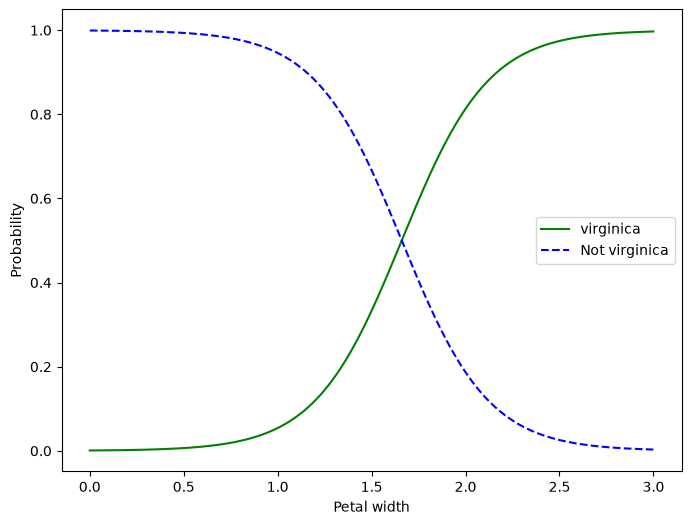

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(X_new, y_proba[:, 1], "g-", label = "virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label = "Not virginica")
plt.legend()
plt.xlabel("Petal width")
plt.ylabel("Probability")
plt.show()

### Petal length와 Petal width에 따른 분류

$X$가 여러 개 있는 경우로도 쉽게 확장할 수 있다.  

Petal length와 Petal width에 따라 virginica 여부를 예측해 보자.

In [23]:
X = iris["data"][:, 2:] # petal length and width
pd.DataFrame(np.c_[X, y], columns=("petal length", "petal width", "virginica"))

,petal length,petal width,virginica
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0
...,...,...,...
145,5.2,2.3,1.0
146,5.0,1.9,1.0
147,5.2,2.0,1.0
148,5.4,2.3,1.0


In [24]:
log_reg2 = LogisticRegression().fit(X, y)
log_reg2.intercept_, log_reg2.coef_

(array([-17.55616979]), array([[2.77983942, 2.38388751]]))

In [25]:
X1_new = np.linspace(0, 7, 1000).reshape(-1, 1) # for petal length
X2_new = np.linspace(0, 3, 1000).reshape(-1, 1) # for petal width

Feature 변수가 두 개이므로, ```predict_proba()```이나 ```predict()```를 사용할 때 인자를 $n\times 2$의 array로 넣어준다.

In [26]:
y_proba = log_reg2.predict_proba(np.c_[X1_new, X2_new])
y_prediction = log_reg2.predict(np.c_[X1_new, X2_new])
df = pd.DataFrame(np.c_[X1_new, X2_new, y_proba, y_prediction], 
             columns=("petal length", "petal width", "p(not virginica)", "p(virginica)", "class"))
df.sample(10).sort_values(["petal length", "petal width"])

,petal length,petal width,p(not virginica),p(virginica),class
56,0.392392,0.168168,1.000000,1.055071e-07,0.0
139,0.973974,0.417417,0.999999,9.626236e-07,0.0
243,1.702703,0.729730,0.999985,1.536603e-05,0.0
420,2.942943,1.261261,0.998288,1.711698e-03,0.0
442,3.097097,1.327327,0.996929,3.071423e-03,0.0
623,4.365365,1.870871,0.723364,2.766361e-01,0.0
776,5.437437,2.330330,0.042522,9.574779e-01,1.0
794,5.563564,2.384384,0.026759,9.732407e-01,1.0
856,5.997998,2.570571,0.005245,9.947552e-01,1.0
917,6.425425,2.753754,0.001037,9.989627e-01,1.0


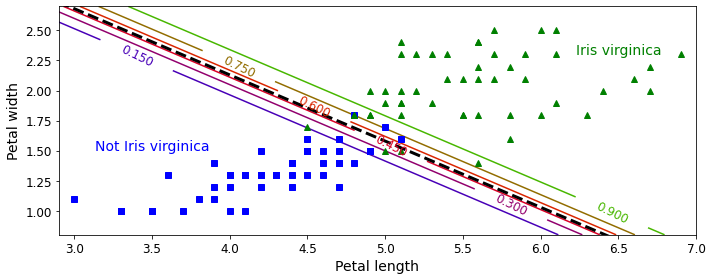

### 여러 클래스에 대한 분류 모형

반응변수 $Y$가 $K$개의 클래스를 가질 때에도 확장 가능하다. $k=1, \cdots, K$에 대해

$$ \mathbb P (Y = k | X) = \frac{e^{\theta^{(k)}_0 + \theta^{(k)}_1 X_1 + \cdots + \theta^{(k)}_p X_p}}{\sum_{\ell=1}^{K}e^{\theta^{(\ell)}_0 + \theta^{(\ell)}_1 X_1 + \cdots + \theta^{(\ell)}_p X_p}} $$

(각 클래스에 대한 총 $K$개의 식이 생성되지만, 실제로는 이 중 $K-1$개의 식이면 충분하다.)

모수들은 각 클래스 $k$에 대해 $\theta^{(k)}_0, \theta^{(k)}_1, \cdots, \theta^{(k)}_p$의 총 $1+p$개가 존재한다.

* 한 클래스를 기준 클래스로 고정하면 자유 모수의 수는 $(K - 1) \times (1 + p)$개가 된다.

* `scikit-learn`은 구현상 클래스별로 $K$개의 계수 벡터를 사용하는 과잉모수화된 표현을 사용한다.

이를 multinomial regression 혹은 softmax regression이라고 부르기도 한다.

(여러 클래스를 가지는 경우, regression외에도 다음에 살펴볼 discriminant analysis를 사용하는 방법도 있다.)

### Softmax function

여러 클래스 분류 문제에서 softmax function이 많이 등장한다.

Softmax function은 임의의 실수로 이루어진 $K$개의 원소를 가지는 벡터 $(z_1, \cdots, z_K)$를 $K$개의 확률값으로 이루어진 벡터로 변환한다.

$k$ 번째 원소에 대해,

$$ \sigma(z_1, \cdots, z_K)_k = \frac{e^{z_k}}{ \sum_{\ell=1}^{K} e^{z_\ell}} $$

즉, 변환된 확률 벡터는 

$$ \left( \frac{e^{z_1}}{ \sum_{\ell=1}^{K} e^{z_\ell}}, \frac{e^{z_2}}{ \sum_{\ell=1}^{K} e^{z_\ell}} , \cdots, \frac{e^{z_K}}{ \sum_{\ell=1}^{K} e^{z_\ell}} \right)^{\top}$$

Multinomial regression에서는 위 식에 $z_i = \theta^{(i)}_0 + \theta^{(i)}_1 X_1 + \cdots + \theta^{(i)}_p X_p$ 대입하여 확률값들을 계산.

### 비용 함수 - cross entropy

다중 클래스 분류(Multi-class classification) 문제에서는 크로스 엔트로피(Cross Entropy)가 비용 함수로 자주 사용된다.

- 크로스 엔트로피는 원래 정보 이론에서 두 확률 분포 간의 유사성을 측정하기 위해 사용되는 개념이다.

- 여기서는 각 샘플에 대해 관측된 정답 $y_i$의 one-hot 인코딩 벡터를 실제 분포로 보고,

   - 3-class 문제에서 $y_i$가 첫번째 클래스 일 때, one-hot 인코딩 : `[1, 0, 0]`  
   - 3-class 문제에서 $y_i$가 두번째 클래스 일 때, one-hot 인코딩 : `[0, 1, 0]`   
   - 3-class 문제에서 $y_i$가 세번째 클래스 일 때, one-hot 인코딩 : `[0, 0, 1]`  <br><br>

- 모형이 추정한 확률 분포 $(p_i^{(1)}, \dots, p_i^{(K)})$가 이와 얼마나 유사한지를 측정하는 데 활용된다.

> 두 분포 간의 크로스 엔트로피 값이 작을수록, 예측 확률 분포가 실제 관측 분포와 더 유사하다고 볼 수 있다.


$K$개의 클래스가 있다고 하자. 다시 말해, $y_i \in \{1, \cdots, K\}$.

앞에서 살펴본 바와 같이, 모델이 추정한 확률 $p_i^{(k)}$, 즉 샘플 $i$가 클래스 $k$에 속할 확률은 다음과 같이 softmax 함수로 정의된다.

$$ p_{i}^{(k)} =  P(y_i = k | x_i, \Theta ) = \frac{\exp(\theta^{(k)} \cdot x_i)}{\sum_{\ell=1}^{K} \exp(\theta^{(\ell)} \cdot x_i)} $$

여기서

$$\Theta = \begin{bmatrix} \theta^{(1)} & \theta^{(2)} & \cdots & \theta^{(K)} \end{bmatrix}$$

이고,

$$ \theta^{(k)} = \begin{bmatrix} \theta^{(k)}_0 & \theta^{(k)}_1 & \cdots & \theta^{(k)}_p \end{bmatrix}^{\top} $$

이다. 

입력 벡터 $x_i$는 상수항을 포함하기 위해 $[1, x_{i1}, \dots, x_{ip}]^\top$이다.

Cross entropy는 다음 식으로 정의한다.

$$ J(\Theta) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{\ell = 1}^{K} y_i^{(\ell)} \log p_{i}^{(\ell)} $$

이며, 여기서

$$ y_i^{(\ell)} = \mathbb {I}_{\{ y_i=\ell \}}. $$

### Gradient for softmax

소프트맥스 회귀의 경우도 그레디언트 벡터를 구할 수 있다.


위에서 살펴본 비용함수 $J$의 $\theta^{(k)}$에 대한 그레디언트 벡터는 다음으로 계산된다.

$$ \nabla_{\theta^{(k)}} J (\Theta) = \begin{bmatrix} \frac{\partial J(\Theta)}{\partial \theta_0^{(k)}} \\ \frac{\partial J(\Theta)}{\partial \theta_1^{(k)}} \\ \vdots \\ \frac{\partial J(\Theta)}{\partial \theta_p^{(k)}}  \end{bmatrix} = \frac{1}{N} \sum_{i=1}^{N} ( p_i^{(k)} - y_i^{(k)} ) x_i .$$

위 식을 유도하기 위해

\begin{align*}
\frac{\partial J(\Theta)}{\partial \theta_j^{(k)}}  &= -\frac{1}{N} \sum_{i=1}^{N} \sum_{\ell = 1}^{K} \frac{\partial}{\partial \theta_j^{(k)}}  y_i^{(\ell)} \log p_i^{(\ell)} \\
&= -\frac{1}{N} \sum_{i=1}^{N} \sum_{\ell = 1}^{K} y_i^{(\ell)} \frac{\partial \log p^{(\ell)}_i }{\partial p^{(\ell)}_i}  \frac{\partial p^{(\ell)}_i}{\partial a_i^{(k)}} \frac{\partial a_i^{(k)}}{\partial \theta_{j}^{(k)}}
\end{align*}

여기서

$$ a_i^{(k)} = \theta^{(k)} \cdot x_i $$ 

이고

$$ \frac{{\partial a_i^{(k)}}}{\partial \theta_{j}^{(k)}} = x_{ij}. $$

따라서

$$\frac{\partial J(\Theta)}{\partial \theta_j^{(k)}} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{\ell = 1}^{K} \frac{y^{(\ell)}_i}{p^{(\ell)}_i}  \frac{\partial p^{(\ell)}_i}{\partial a_i^{(k)}}  x_{ij}.$$

또한, 만약 $\ell = k$ 이면,
$$ \frac{\partial p^{(\ell)}_i}{\partial a_i^{(k)}} = \frac{\partial p^{(\ell)}_i}{\partial a_i^{(\ell)}} = \frac{\partial}{\partial a_i^{(\ell)}} \frac{\exp(a_i^{(\ell)})}{\sum_{m=1}^{K} \exp(a_i^{(m)})} = \frac{\exp(a_i^{(\ell)})\sum_{m=1}^{K} \exp(a_i^{(m)}) -  \exp(a_i^{(\ell)}) \exp(a_i^{(\ell)})}{ (\sum_{m=1}^{K} \exp(a_i^{(m)}) )^2 } = p^{(\ell)}_i \left( 1 - p^{(\ell)}_i \right) $$
이고, 만약 $\ell \neq k$ 이면
$$ \frac{\partial p^{(\ell)}_i}{\partial a_i^{(k)}} =  - \frac{ \exp(a_i^{(\ell)}) \exp(a_i^{(k)})}{ (\sum_{m=1}^{K} \exp(a_i^{(m)}) )^2 } = -  p^{(k)}_i p^{(\ell)}_i$$
이다.

그러므로,
\begin{align*}
\frac{\partial J(\Theta)}{\partial \theta_j^{(k)}} &= -\frac{1}{N} \sum_{i=1}^{N} \left( y_i^{(k)} (1 - p_i^{(k)} )  - \sum_{\ell \neq k} p_i^{(k)} y_i^{(\ell)} \right) x_{ij} \\
&=  -\frac{1}{N} \sum_{i=1}^{N} \left(y_i^{(k)} - p_i^{(k)} \left(y_i^{(k)}  + \sum_{\ell \neq k} y_i^{(\ell)}\right) \right) x_{ij}  \\
& = \frac{1}{N} \sum_{i=1}^N (p_i^{(k)} - y_i^{(k)} ) x_{ij}.
\end{align*}
이다.

위 식에서 $p_i^{(k)}$가 $\theta^{(k)}$에 대한 함수이며, $x_{ij}$와 $y_i^{(k)}$는 관찰값들이다.

모든 클래스 $k$들에 대하여도 위와 같은 그레디언트 벡터를 유도하면, 전체 gradient는 다음과 같다.

$$
\nabla_\Theta J(\Theta) = \frac{1}{N} \mathbf{X}_b^\top (\mathbf{P} - \mathbf{Y}) 
$$

- $\mathbf{P}$ : softmax 확률 행렬로 각 행은 $p_i^{(k)}$
  
- $\mathbf{Y}$ : one-hot encoded 정답 레이블 행렬로 각 행은 $y_i^{(k)}$

### 두 개의 feature 변수와 3 개의 class

두 개의 입력 변수인 petal length, petal width로 3가지 서로 다른 붓꽃 품종을 예측하는 모형을 고려해 보자.

In [27]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

In [28]:
pd.DataFrame(np.c_[X, y], columns=("petal length", "petal_width", "target"))

,petal length,petal_width,target
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0
...,...,...,...
145,5.2,2.3,2.0
146,5.0,1.9,2.0
147,5.2,2.0,2.0
148,5.4,2.3,2.0


마찬가지로 ```sklearn.linear_model.LogisticRegression```를 이용한다.

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
softmax_reg = LogisticRegression(solver="lbfgs")

In [31]:
softmax_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [32]:
softmax_reg.intercept_, softmax_reg.coef_

(array([ 11.12427971,   3.22544055, -14.34972026]),
 array([[-2.7476411 , -1.1703017 ],
        [ 0.08364114, -0.90695071],
        [ 2.66399996,  2.07725241]]))

In [33]:
# 인자 : {array-like, sparse matrix} of shape (n_samples, n_features)
softmax_reg.predict([[5, 2]]) # petal length 5, petal width 2

array([2])

In [34]:
softmax_reg.predict_proba([[5, 2]])

array([[2.43199208e-04, 2.14948752e-01, 7.84808048e-01]])

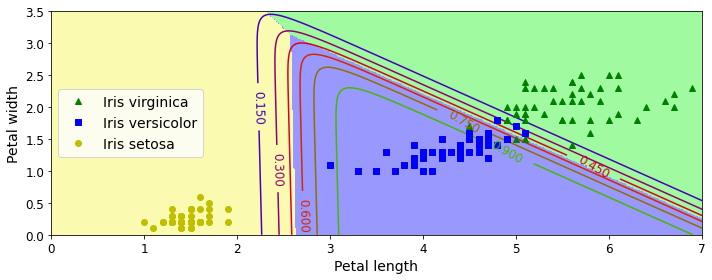

### with sepal length and sepal width

In [35]:
X = iris.data[:, :2]  # we only take the first two features.
Y = iris.target

# Create an instance of Logistic Regression Classifier and fit the data.
logreg = LogisticRegression()

In [36]:
logreg.fit(X, Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
logreg.intercept_, logreg.coef_

(array([ 7.91140003,  1.84697777, -9.75837781]),
 array([[-2.70858405,  2.32402607],
        [ 0.61260073, -1.57100532],
        [ 2.09598332, -0.75302075]]))

입력 변수에 대한 Meshgrid를 생성하여, 각 meshpoint에 대해 class를 예측해 보자.

Meshgrid의 모든 point에 대해 class prediction을 하기 위해, ```predict``` 메소드의 인자로 ```np.c_[xx.ravel(), yy.ravel()]```를 대입한 후, 결과를 meshgrid 형태로 ```reshape``` 하였다.

* ```ravel()```로 2차원 array를 1차원으로 flat할 수 있다.

```for``` loop를 돌려 계산할 수도 있지만, 아래의 방법이 더 빠르다.

In [38]:
x_min, x_max = 3.5, 8.5
y_min, y_max = 1.5, 5
h = 0.01  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])   # raval : Return a contiguous flattened array.

Z = Z.reshape(xx.shape)
pd.DataFrame(Z)

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0,0,0,0,0,0,0,0,0,1,...,2,2,2,2,2,2,2,2,2,2
1,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
2,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
3,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
4,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
346,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
347,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
348,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2


아래 코드에서 ```pcolormesh```로 컬러맵을 작성하였다.  

Scatter plot은 훈련에 사용한 관찰값들이다.

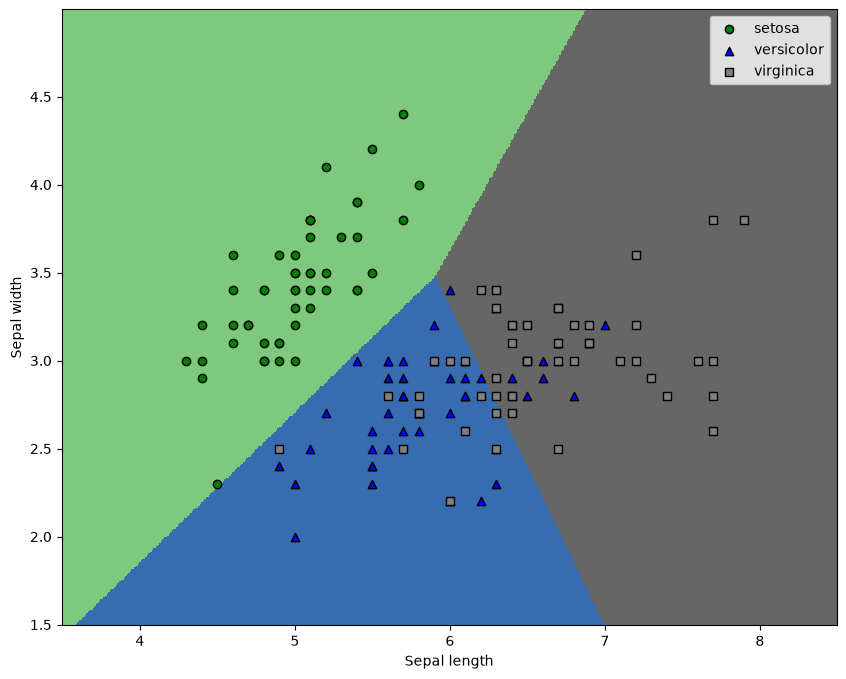

In [39]:
plt.figure(1, figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Accent)

plt.scatter(X[Y==0, 0], X[Y==0, 1], edgecolors="k", marker="o", color="green", label='setosa')
plt.scatter(X[Y==1, 0], X[Y==1, 1], edgecolors="k", marker="^", color="blue", label='versicolor')
plt.scatter(X[Y==2, 0], X[Y==2, 1], edgecolors="k", marker="s", color="grey", label='virginica')

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.legend()

plt.show()

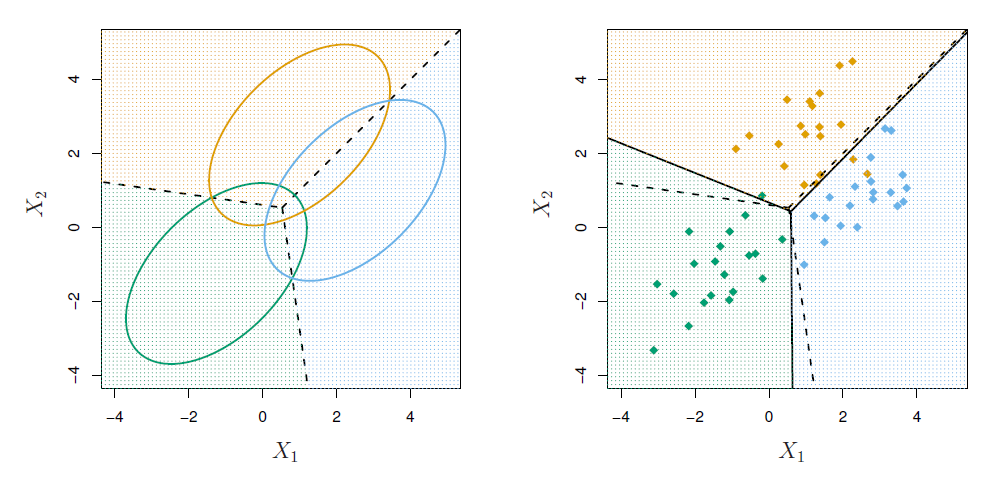